### Analisis Karakteristik dan Faktor Penentu Karyawan yang Resign (Employee Churn Analysis)

In [ ]:
from pandas import DataFrame
import pandas as pd
import numpy as np

df = pd.read_csv("Employee.csv")
(df)


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [ ]:
LeaveOrNot_index = ['LeaveOrNot']
LeaveOrNot_df = df [['LeaveOrNot']]
LeaveOrNot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   LeaveOrNot  4653 non-null   int64
dtypes: int64(1)
memory usage: 36.5 KB


In [ ]:
LeaveOrNot_df.isnull().values.any()
LeaveOrNot_df.isnull().sum()

LeaveOrNot    0
dtype: int64

In [ ]:
df.LeaveOrNot.value_counts()

0    3053
1    1600
Name: LeaveOrNot, dtype: int64

In [ ]:
df_attribute = df.drop(LeaveOrNot_df, axis=1)
df_attribute.info()
df_attribute.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 290.9+ KB


(4653, 8)

In [ ]:
df_attribute.isnull().values.any()
df_attribute.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
dtype: int64

In [ ]:
kategori_df = df.select_dtypes(include=['object'])
kategori_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Education    4653 non-null   object
 1   City         4653 non-null   object
 2   Gender       4653 non-null   object
 3   EverBenched  4653 non-null   object
dtypes: object(4)
memory usage: 145.5+ KB


In [ ]:
numerik_df = df.select_dtypes(include=['int64','float64'])
numerik_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   JoiningYear                4653 non-null   int64
 1   PaymentTier                4653 non-null   int64
 2   Age                        4653 non-null   int64
 3   ExperienceInCurrentDomain  4653 non-null   int64
 4   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5)
memory usage: 181.9 KB


In [ ]:
numerik_index = numerik_df.columns
numerik_index

Index(['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain',
       'LeaveOrNot'],
      dtype='object')

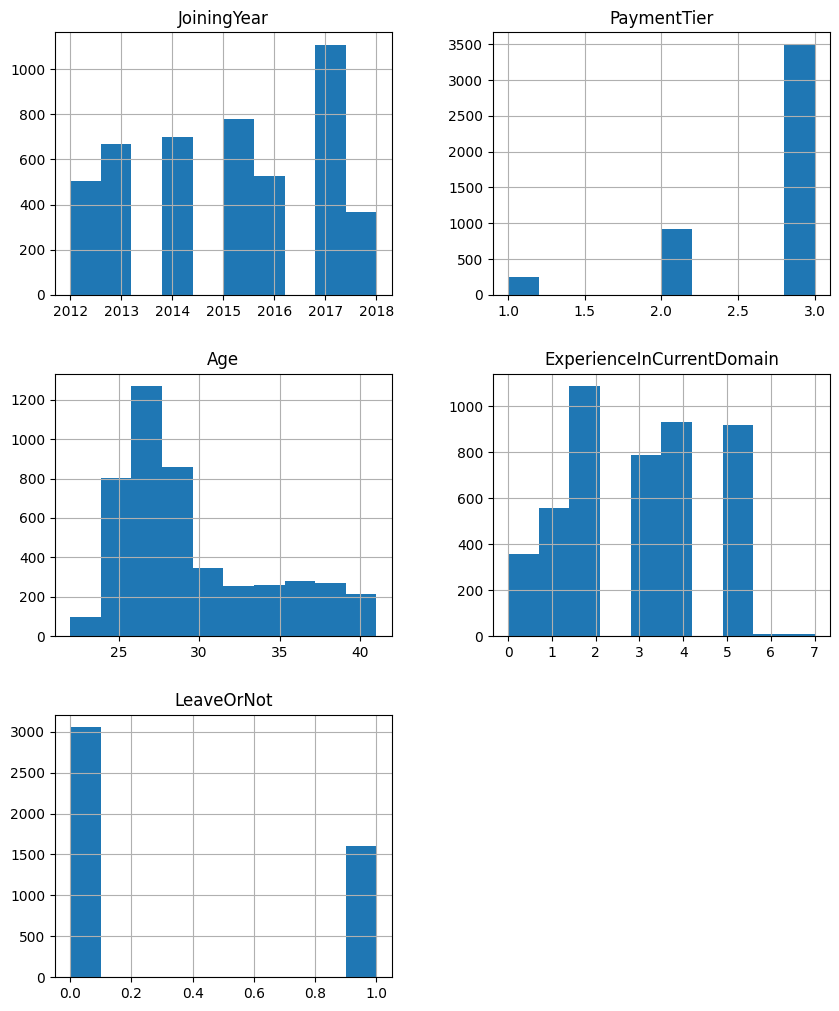

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
df.hist(column=numerik_index,figsize=(10,30),layout=(7,2))
plt.show()

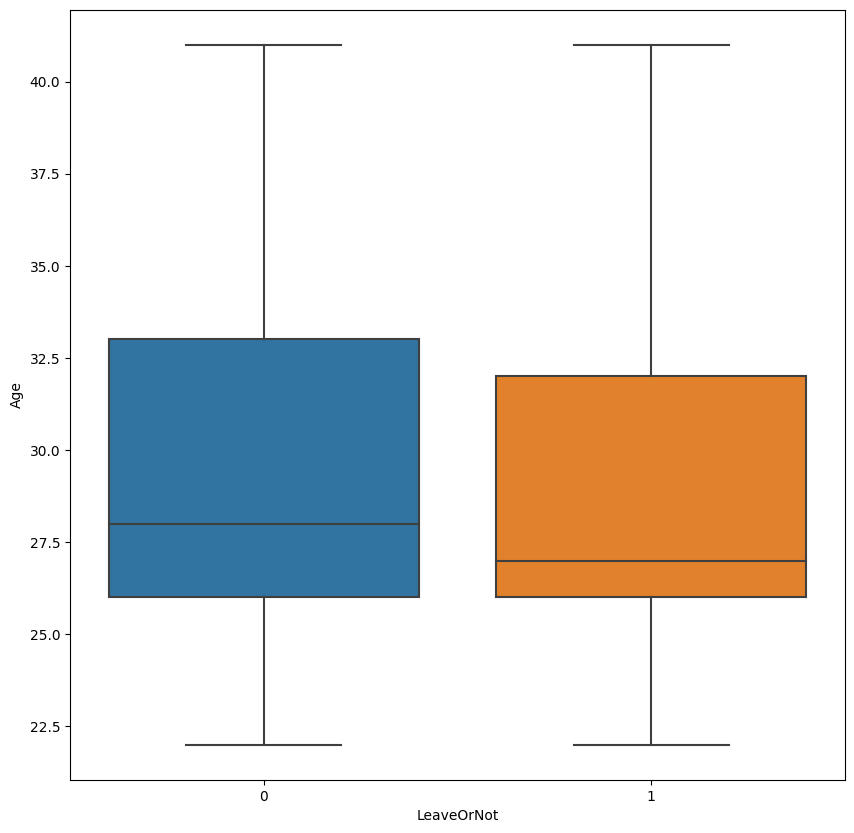

In [ ]:
import seaborn as sns
fig = plt.figure(figsize=(10,10))
sns.boxplot(x="LeaveOrNot",y="Age",data=df)
plt.show()

In [ ]:
df[['LeaveOrNot','Age']].groupby(['LeaveOrNot'],as_index=False).mean().sort_values(by='Age', ascending=False)

,LeaveOrNot,Age
0,0,29.571896
1,1,29.052500


In [ ]:
import random
from scipy.stats import ttest_ind,ttest_rel
from scipy import stats

df = df[(np.abs(stats.zscore(df["Age"]))<3)]

income_1 = df[df['LeaveOrNot']==0]['Age']
income_0 = df[df['LeaveOrNot']==1]['Age']

income_0 = income_0.values.tolist()
income_0 = random.sample(income_0,12)
income_1 = income_1.values.tolist()
income_1 = random.sample(income_1,12)

ttest,pval = ttest_ind(income_1,income_0,equal_var=False)
print('ttest',ttest)
print('p value',pval)

if pval<0.05:
  print("H0 ditolak")
else:
  print("H0 diterima")


ttest 0.0
p value 1.0
H0 diterima


In [ ]:
import random
from scipy.stats import ttest_ind,ttest_rel
from scipy import stats

df = df[(np.abs(stats.zscore(df["PaymentTier"]))<3)]

income_1 = df[df['LeaveOrNot']==0]['PaymentTier']
income_0 = df[df['LeaveOrNot']==1]['PaymentTier']

income_0 = income_0.values.tolist()
income_0 = random.sample(income_0,12)
income_1 = income_1.values.tolist()
income_1 = random.sample(income_1,12)

ttest,pval = ttest_ind(income_1,income_0,equal_var=False)
print('ttest',ttest)
print('p value',pval)

if pval<0.05:
  print("H0 ditolak")
else:
  print("H0 diterima")


ttest 2.9340578815309546
p value 0.009145274740115792
H0 ditolak


In [ ]:
import random
from scipy.stats import ttest_ind,ttest_rel
from scipy import stats

df = df[(np.abs(stats.zscore(df["JoiningYear"]))<3)]

income_1 = df[df['LeaveOrNot']==0]['JoiningYear']
income_0 = df[df['LeaveOrNot']==1]['JoiningYear']

income_0 = income_0.values.tolist()
income_0 = random.sample(income_0,12)
income_1 = income_1.values.tolist()
income_1 = random.sample(income_1,12)

ttest,pval = ttest_ind(income_1,income_0,equal_var=False)
print('ttest',ttest)
print('p value',pval)

if pval<0.05:
  print("H0 ditolak")
else:
  print("H0 diterima")


ttest -0.5423261445467391
p value 0.5932758683118016
H0 diterima


In [ ]:
def bar_chart(feature):
  Accepted = df[df['LeaveOrNot']==0][feature].value_counts()
  Rejected = df[df['LeaveOrNot']==1][feature].value_counts()
  df1 = pd.DataFrame([ Accepted,Rejected])
  df1.index = ['Accepted','Rejected']
  df1.plot(kind='bar',stacked=True,fig=(18,6),title=feature)


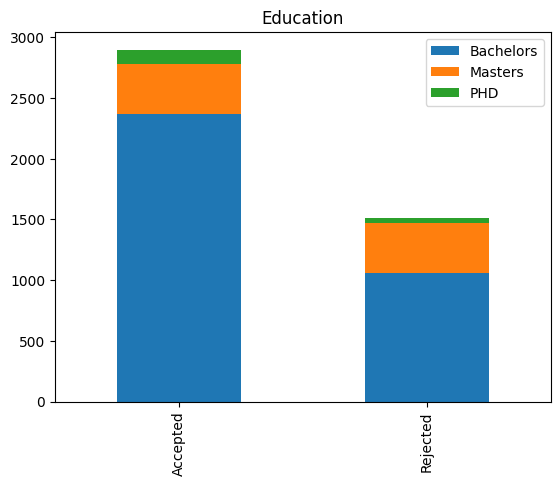

In [ ]:
bar_chart('Education')

In [ ]:
c_t = pd.crosstab(df['Education'],df['LeaveOrNot'],margins=False)
c_t

LeaveOrNot,0,1
Education,,
Bachelors,2366,1062
Masters,410,407
PHD,123,42


In [ ]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2

stat,p,dof,expected = chi2_contingency(c_t)
print('dof=%d' % dof)
print('p value',p)
print(expected)

prob = 0.99
critical=chi2.ppf(prob,dof)
print('probabilitas=%.3f, critical=%.3f,stat=%.3f'%(prob,critical,stat))
if abs(stat)>= critical:
  print('Dependent (tolak H0)')
else:
  print('independent (terima H0)')

dof=2
p value 1.4119054395820203e-24
[[2253.46303855 1174.53696145]
 [ 537.07097506  279.92902494]
 [ 108.46598639   56.53401361]]
probabilitas=0.990, critical=9.210,stat=109.834
Dependent (tolak H0)


<ipython-input-57-85dfe304fdfe>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  cor = df.corr()


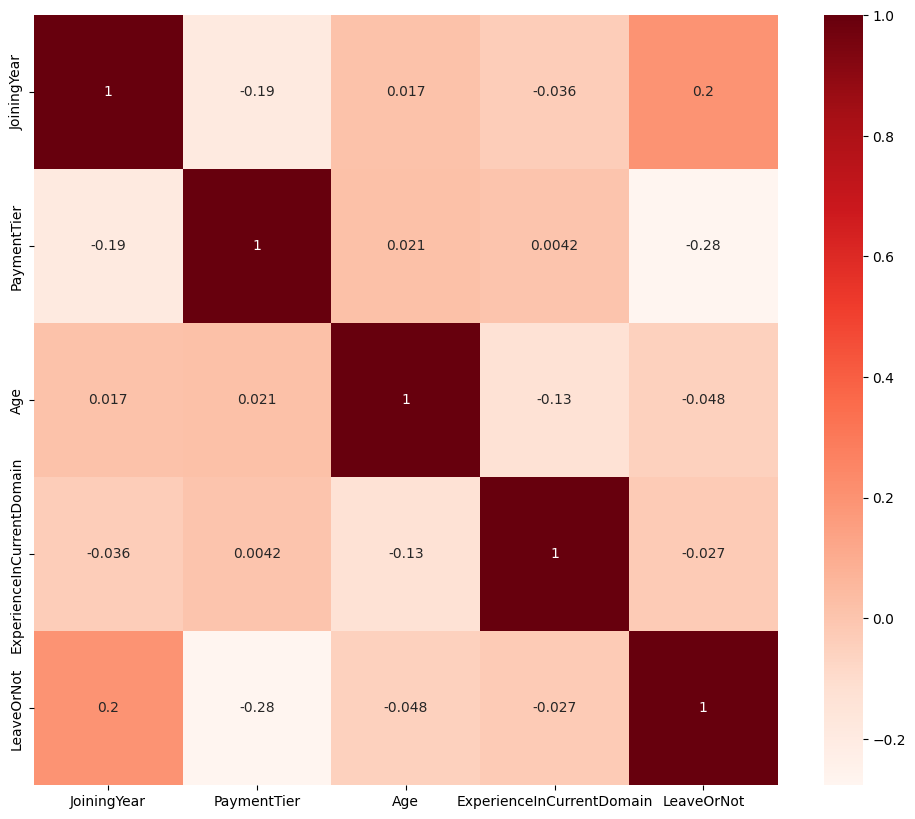

JoiningYear    0.197169
PaymentTier    0.277109
LeaveOrNot     1.000000
Name: LeaveOrNot, dtype: float64

In [ ]:
plt.figure(figsize=(12,10))
cor = df.corr()
sns.heatmap(cor, annot=True,cmap=plt.cm.Reds)
plt.show()
cor_target = abs(cor['LeaveOrNot'])
relevant_features = cor_target[cor_target>0.1]
relevant_features

### Kesimpulan

1. Tingkat Gaji (PaymentTier) dan Tingkat Pendidikan (Education) terbukti memiliki pengaruh paling signifikan terhadap keputusan karyawan untuk keluar.
2. Karyawan lulusan Masters memiliki kecenderungan resign yang jauh lebih tinggi dibandingkan lulusan Bachelors atau PHD.
3. Tingkat pembayaran (PaymentTier) memiliki korelasi linier terkuat terhadap keputusan resign.
4. Usia (Age) tidak menunjukkan perbedaan atau pengaruh yang signifikan secara statistik antara karyawan yang bertahan dan yang keluar.